In [1]:
import torch
from torchvision import datasets, models, transforms
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
from Trainer import Trainer
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tqdm import tqdm

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
class TransferLearningNetwork(nn.Module):
    def __init__(self):
        super(TransferLearningNetwork, self).__init__()

        # Load pre-trained ResNet model
        resnet = models.resnet152(weights=models.ResNet152_Weights.DEFAULT).to(device)

        # Freeze the parameters of the pre-trained ResNet
        for param in resnet.parameters():
            param.requires_grad = False

        # Modify the last layer to match the number of classes
        num_ftrs = resnet.fc.in_features
        resnet.fc = nn.Sequential(
                            nn.Linear(num_ftrs, 1),
                            nn.Sigmoid()).to(device)

        self.resnet = resnet

    def forward(self, x):
        x = self.resnet(x)
        return x.view(-1)

In [3]:
model = TransferLearningNetwork()
model.load_state_dict(torch.load("/zhome/bd/4/181258/02514/models/resnet_512_64"))
model.eval()

TransferLearningNetwork(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequent

In [4]:
import torchvision.transforms.functional as TTF
# https://discuss.pytorch.org/t/how-to-resize-and-pad-in-a-torchvision-transforms-compose/71850/5

image_size = 512

class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_wh = np.max([w, h])
        hp = int((max_wh - w) / 2)
        vp = int((max_wh - h) / 2)
        padding = (hp, vp, hp, vp)
        return TTF.pad(image, padding, 0, 'constant')

# now use it as the replacement of transforms.Pad class
transform=transforms.Compose([
    SquarePad(),
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor()
])

normalize = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

batch_size = 64
trainset = datasets.ImageFolder(root="/dtu/datasets1/02514/hotdog_nothotdog/train/", transform=transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=1)
testset = datasets.ImageFolder(root="/dtu/datasets1/02514/hotdog_nothotdog/test/", transform=transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=1)

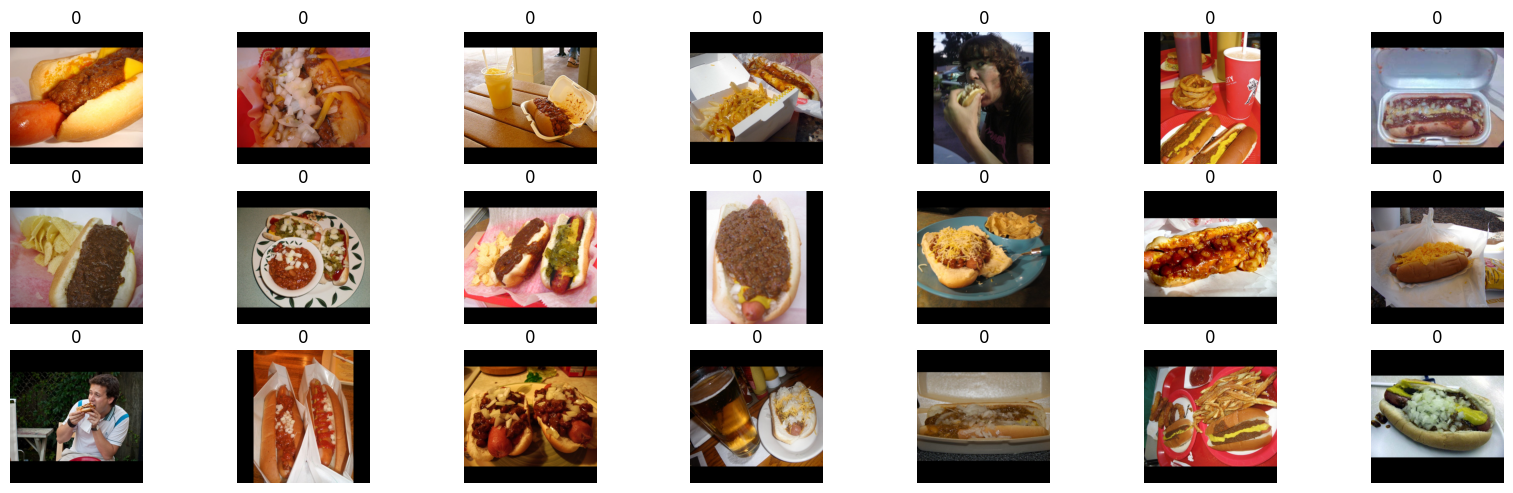

In [5]:
images, labels = next(iter(test_loader))
plt.figure(figsize=(20,10))

for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(images[i].numpy().transpose(1,2,0))
    plt.title(labels[i].item())
    plt.axis('off')

In [6]:
def get_saliency(image, label, sigma=0.1, n_samples=10):
    grads = []

    for i in tqdm(range(n_samples)):
        # Add gaussian noises
        noised_image = image + torch.randn(image.size()) * (sigma / (image.max() - image.min()))
        noised_image = noised_image.to(device)

        X = normalize(noised_image).to(device)
        X.requires_grad_()

        output = model(X.unsqueeze(0))
        output.backward()

        # Sample the gradients on the pixel-space
        grad = X.grad.data.cpu().numpy()
        grads.append(grad)

    grad = np.mean(np.array(grads), axis=0)
    saliency = np.max(np.abs(grad), axis=0)
    saliency -= saliency.min()
    saliency /= saliency.max()
    saliency = np.uint8(saliency * 255)
    
    # Visualize the image and the saliency map
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(image.cpu().detach().numpy().transpose(1, 2, 0))
    ax[0].axis('off')
    ax[1].imshow(saliency, cmap='hot')
    ax[1].axis('off')
    plt.tight_layout()
    hclass = "hotdog" if label.cpu().detach() == 0 else "not-hotdog"
    fig.suptitle(f'The {hclass} and its saliency map')
    plt.show()

100%|███████████████████████████████████████████████████████████████████████████| 50/50 [00:06<00:00,  7.38it/s]


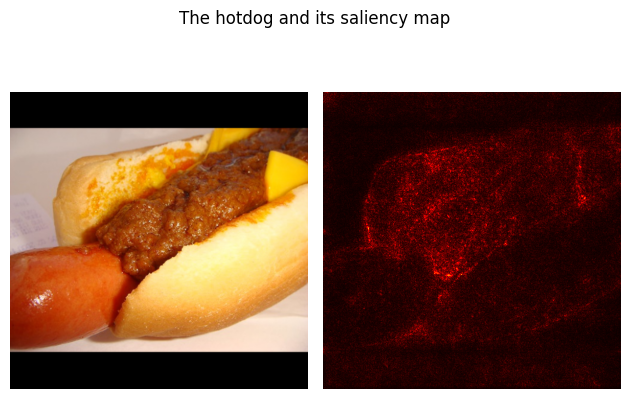

In [7]:
get_saliency(images[0], labels[0], sigma=0.1, n_samples=50)

100%|███████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 13.32it/s]


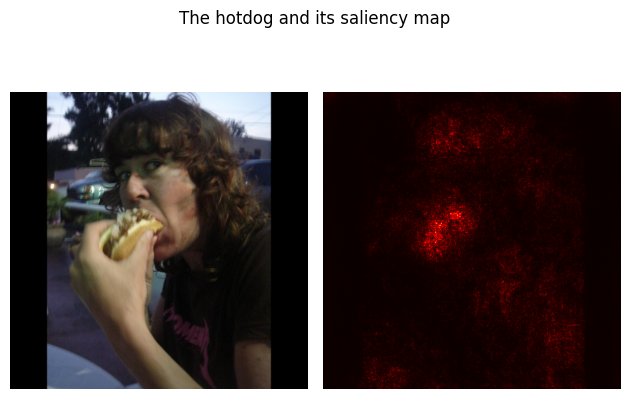

In [8]:
get_saliency(images[4], labels[4], sigma=0.01, n_samples=50)

In [9]:
trainer = Trainer(data_path="/dtu/datasets1/02514/hotdog_nothotdog/",
                 image_size=512,
                 batch_size=64,
                 normalize=True)

The code will run on GPU.


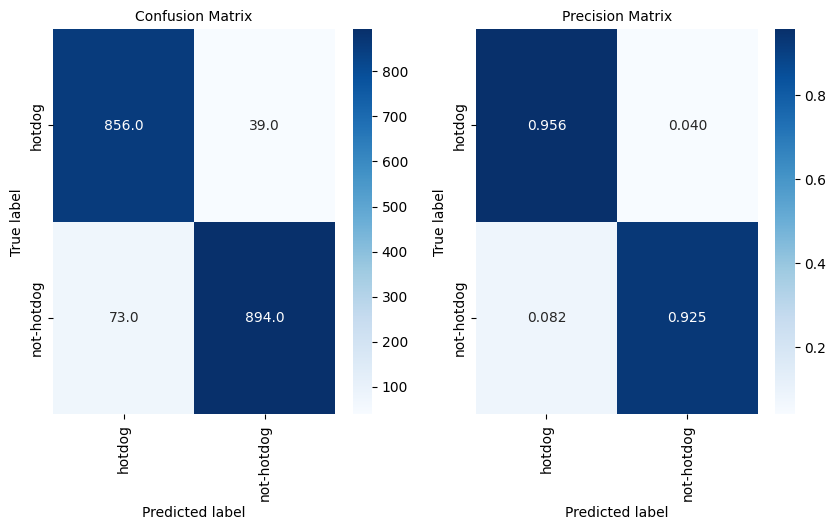

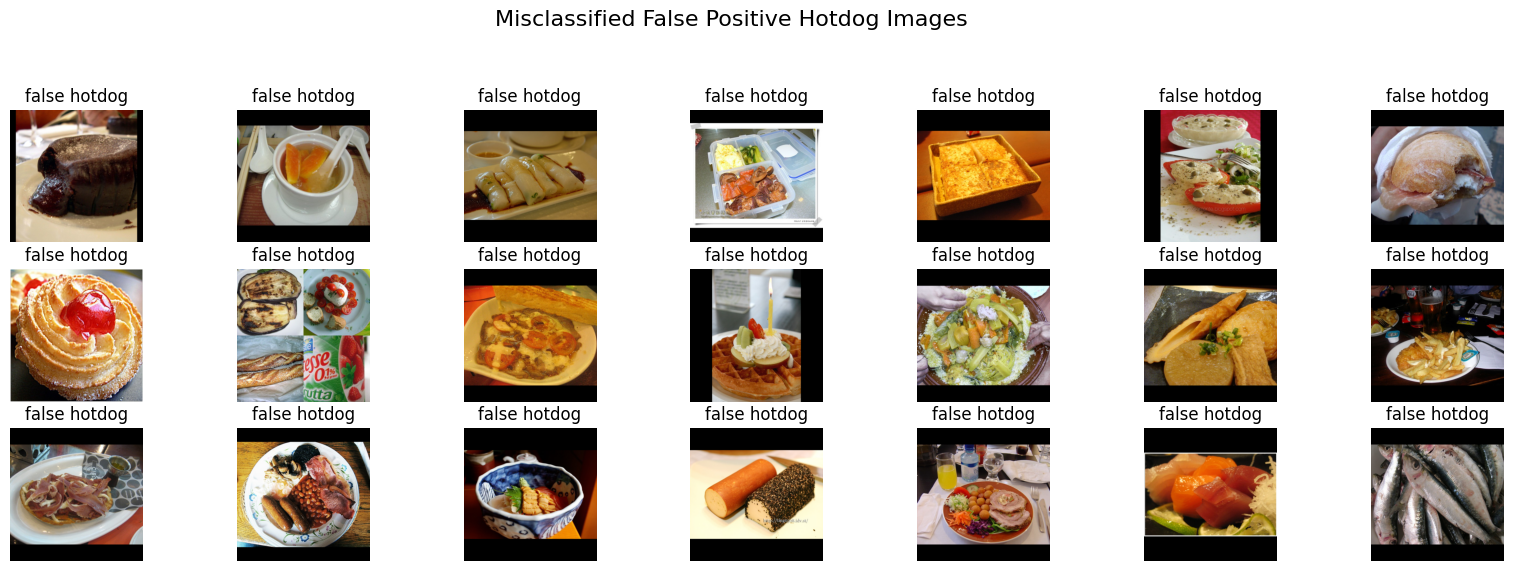

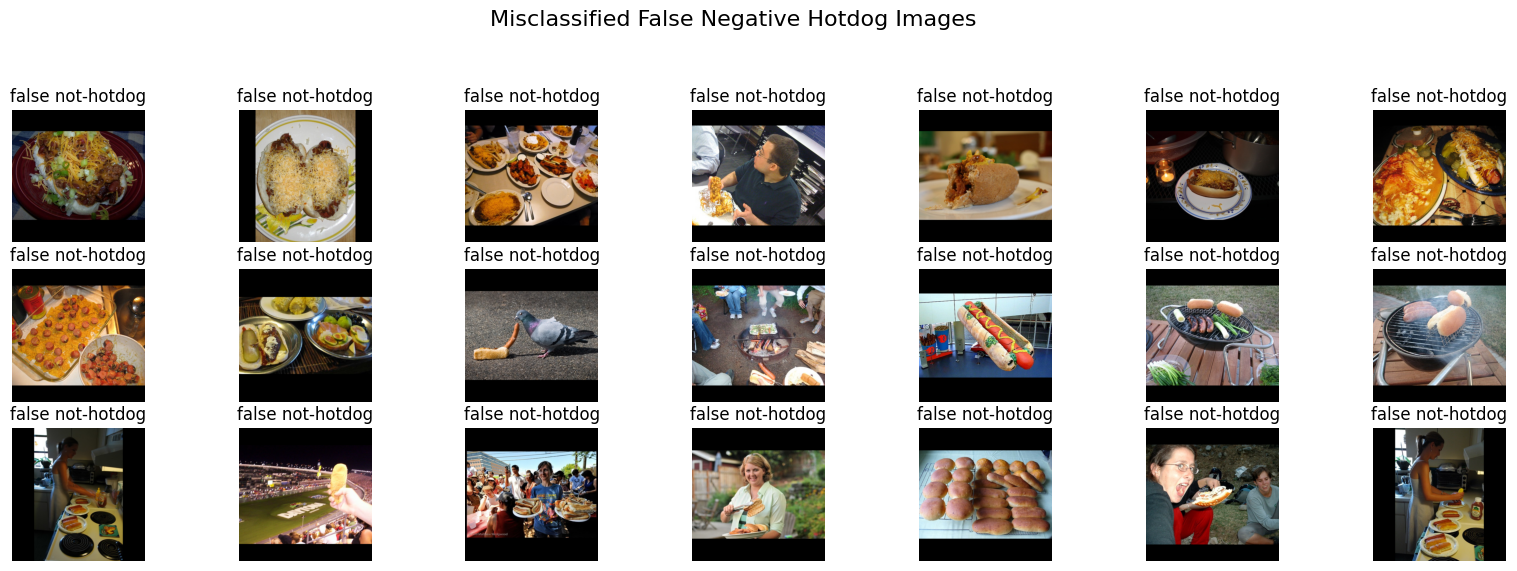

In [10]:
trainer.confusionMatrix(model, show_images = True)

100%|███████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 13.83it/s]


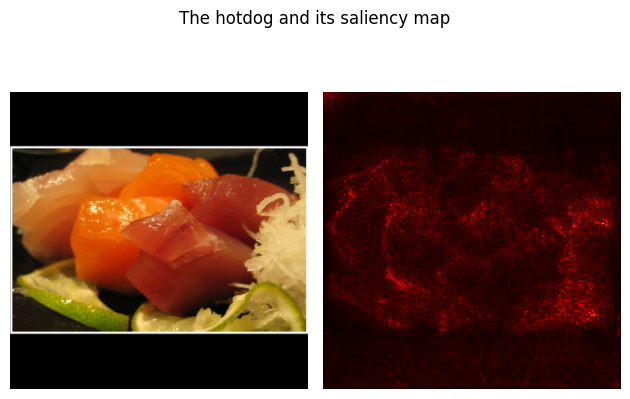

In [14]:
get_saliency(trainer.false_positive[19], labels[4], sigma=0.1, n_samples=50)